# Fine-Tuning Qwen3-0.6B as a Clinical AI Assistant

End-to-end notebook that QLoRA-fine-tunes `Qwen/Qwen3-0.6B` with **Unsloth** on two Kaggle symptom→disease datasets, evaluates Base vs. Fine-tuned with Accuracy / F1-macro / Cohen's Kappa / Confusion Matrix / BERTScore, and exports a **GGUF** artifact for local inference.

**Target hardware:** Google Colab Free (Tesla T4, 16 GB VRAM, ~12 GB RAM).

> ⚠️ **Disclaimer:** the resulting model is an *auxiliary* tool for healthcare professionals only. It is **not** a substitute for a professional medical diagnosis.


## 1. Set Up the Workspace

Install Unsloth + the training/evaluation stack, confirm Kaggle credentials are available, and verify the GPU is reachable.

In [1]:
%%capture
# 1. Installing Unsloth and the zoo (clean, no duplicates, and with the new colab extras)
!pip install --upgrade --no-cache-dir unsloth
!pip install --no-deps unsloth_zoo

# 2. Training and evaluation dependencies
!pip install bitsandbytes trl peft accelerate datasets \
             kagglehub evaluate bert_score scikit-learn \
             matplotlib seaborn pandas sentencepiece protobuf


In [ ]:
# --- Imports, reproducibility, credential check, and GPU sanity check ---
import os
import re
import gc
import random
import warnings
from pathlib import Path

from unsloth import FastLanguageModel
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 3407
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")

kaggle_username = os.getenv("KAGGLE_USERNAME")
kaggle_key = os.getenv("KAGGLE_KEY")
if not kaggle_username or not kaggle_key:
    print("Kaggle credentials not found in environment. In Colab, set KAGGLE_USERNAME and KAGGLE_KEY before download.")
else:
    print(f"Kaggle credentials detected for user: {kaggle_username}")

assert torch.cuda.is_available(), "CUDA GPU is required (Colab T4 recommended)."
gpu_name = torch.cuda.get_device_name(0)
total_mem_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
print(f"GPU: {gpu_name}")
print(f"Total VRAM: {total_mem_gb:.1f} GB")
print(f"PyTorch: {torch.__version__} | CUDA: {torch.version.cuda}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Kaggle credentials not found in environment. In Colab, set KAGGLE_USERNAME and KAGGLE_KEY before download.
GPU: Tesla T4
Total VRAM: 14.6 GB
PyTorch: 2.10.0+cu128 | CUDA: 12.8


In [8]:
# --- Global configuration ---
CONFIG = {
    # Model
    "base_model_id":   "unsloth/Qwen3-0.6B-unsloth-bnb-4bit",
    "max_seq_length":  1024,
    "load_in_4bit":    True,

    # LoRA
    "lora_r":           16,
    "lora_alpha":       32,
    "lora_dropout":     0.0,
    "target_modules":  ["q_proj", "k_proj", "v_proj", "o_proj",
                        "gate_proj", "up_proj", "down_proj"],

    # Training
    "per_device_train_batch_size": 2,
    "gradient_accumulation_steps": 4,
    "warmup_steps":                20,
    "max_steps":                  400,
    "learning_rate":             2e-4,
    "weight_decay":              0.01,
    "logging_steps":               20,
    "fp16":                      True,
    "bf16":                      False,
    "optim":              "adamw_8bit",
    "lr_scheduler_type":     "linear",

    # Data
    "ds1_max_per_disease":   50,    # stratified cap on the large dataset
    "test_size":             0.10,
    "thinking_ratio":        0,  

    # Eval
    "eval_max_samples":     300,    # per-source cap for headline metrics
    "qualitative_n":          8,
    "bertscore_model_type": "distilbert-base-uncased",  # lighter than roberta-large for T4

    # Paths
    "output_dir":         "outputs",
    "lora_dir":           "qwen3-clinical-lora",
    "gguf_dir":           "qwen3-clinical-gguf",
    "seed":               SEED,
}

SYSTEM_PROMPT = (
    "You are a clinical AI assistant. Given a patient's reported symptoms, "
    "respond with the most likely disease using the standardized disclaimer format."
)

DISCLAIMER_TEMPLATE = (
    "Based on the reported symptoms, the clinical indication points to: {disease}.\n"
    "Disclaimer: This is an AI auxiliary tool designed for healthcare professionals. "
    "It is not 100% precise and does not replace a professional medical diagnosis."
)

print("Config loaded.")


Config loaded.


## 2. Define Inputs and Configuration

Download both Kaggle datasets via `kagglehub`, normalize them into a unified `{instruction, input, output}` schema, and prepare train/test splits for training and evaluation.

### 2.1 — Download datasets

In [9]:
import kagglehub

ds1_path = kagglehub.dataset_download("dhivyeshrk/diseases-and-symptoms-dataset")
ds2_path = kagglehub.dataset_download("niyarrbarman/symptom2disease")

print("Dataset 1 root:", ds1_path)
print("Dataset 2 root:", ds2_path)


def _find_csv(root: str, hint: str) -> str:
    """Pick the CSV under `root` whose name contains `hint` (case-insensitive)."""
    candidates = [p for p in Path(root).rglob("*.csv")]
    if not candidates:
        raise FileNotFoundError(f"No CSV under {root}")
    matches = [p for p in candidates if hint.lower() in p.name.lower()]
    chosen = matches[0] if matches else candidates[0]
    return str(chosen)


DS1_CSV = _find_csv(ds1_path, "Final_Augmented")
DS2_CSV = _find_csv(ds2_path, "Symptom2Disease")
print("DS1 CSV:", DS1_CSV)
print("DS2 CSV:", DS2_CSV)


100%|██████████| 2.81M/2.81M [00:00<00:00, 44.9MB/s]

Extracting files...


100%|██████████| 43.6k/43.6k [00:00<00:00, 41.3MB/s]

Extracting files...
Dataset 1 root: /root/.cache/kagglehub/datasets/dhivyeshrk/diseases-and-symptoms-dataset/versions/1
Dataset 2 root: /root/.cache/kagglehub/datasets/niyarrbarman/symptom2disease/versions/1
DS1 CSV: /root/.cache/kagglehub/datasets/dhivyeshrk/diseases-and-symptoms-dataset/versions/1/Final_Augmented_dataset_Diseases_and_Symptoms.csv
DS2 CSV: /root/.cache/kagglehub/datasets/niyarrbarman/symptom2disease/versions/1/Symptom2Disease.csv


## 3. Create Helper Functions

### 3.1 — Dataset 1: binary symptom matrix → natural language

Each row has one disease column and 377 binary symptom columns (1 = symptom present).
We collect every symptom whose value is `1`, prettify the column name, and join
with commas. The disease becomes the `output`.

In [10]:
df_ds1 = pd.read_csv(DS1_CSV)
print('Columns:', df_ds1.columns.tolist())
print('Types:', df_ds1.dtypes)
display(df_ds1.head())
display(df_ds1["diseases"].value_counts())

Columns: ['diseases', 'anxiety and nervousness', 'depression', 'shortness of breath', 'depressive or psychotic symptoms', 'sharp chest pain', 'dizziness', 'insomnia', 'abnormal involuntary movements', 'chest tightness', 'palpitations', 'irregular heartbeat', 'breathing fast', 'hoarse voice', 'sore throat', 'difficulty speaking', 'cough', 'nasal congestion', 'throat swelling', 'diminished hearing', 'lump in throat', 'throat feels tight', 'difficulty in swallowing', 'skin swelling', 'retention of urine', 'groin mass', 'leg pain', 'hip pain', 'suprapubic pain', 'blood in stool', 'lack of growth', 'emotional symptoms', 'elbow weakness', 'back weakness', 'pus in sputum', 'symptoms of the scrotum and testes', 'swelling of scrotum', 'pain in testicles', 'flatulence', 'pus draining from ear', 'jaundice', 'mass in scrotum', 'white discharge from eye', 'irritable infant', 'abusing alcohol', 'fainting', 'hostile behavior', 'drug abuse', 'sharp abdominal pain', 'feeling ill', 'vomiting', 'headache

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


,count
diseases,
cystitis,1219
vulvodynia,1218
nose disorder,1218
complex regional pain syndrome,1217
spondylosis,1216
...,...
thalassemia,1
huntington disease,1
typhoid fever,1


In [11]:
DS1_INSTRUCTION = "Given the symptoms, identify the disease."


def _prettify_symptom(col: str) -> str:
    """Convert e.g. 'shortness_of_breath' -> 'shortness of breath'."""
    return re.sub(r"[_\-]+", " ", col).strip().lower()


def build_ds1(df: pd.DataFrame, max_per_disease: int, seed: int) -> pd.DataFrame:
    # First column is the disease label; the rest are 0/1 symptom flags.
    disease_col = df.columns[0]
    symptom_cols = [c for c in df.columns[1:]]
    pretty = {c: _prettify_symptom(c) for c in symptom_cols}

    # Vectorised: for each row collect the symptom column names where value == 1.
    sym_matrix = df[symptom_cols].to_numpy(dtype=np.int8)
    rows = []
    for i, disease in enumerate(df[disease_col].astype(str).values):
        active = np.flatnonzero(sym_matrix[i] == 1)
        if active.size == 0:
            continue
        symptoms = ", ".join(pretty[symptom_cols[j]] for j in active)
        rows.append({
            "instruction": DS1_INSTRUCTION,
            "input":  symptoms,
            "output": disease.strip(),
            "source": "ds1_diseases_symptoms",
        })

    out = pd.DataFrame(rows)
    
    # Stratified cap: at most N rows per disease.
    out = (
        out.sample(frac=1, random_state=seed)
        .groupby("output")
        .head(max_per_disease)
        .reset_index(drop=True)
    )
    # Drop diseases with <2 rows so stratified split is feasible later.
    counts = out["output"].value_counts()
    keep = counts[counts >= 2].index
    out = out[out["output"].isin(keep)].reset_index(drop=True)
    
    return out


ds1 = build_ds1(df_ds1, CONFIG["ds1_max_per_disease"], SEED)
print(f"DS1 rows: {len(ds1):,}  |  unique diseases: {ds1['output'].nunique()}")
ds1.head(3)
ds1["output"].value_counts()


DS1 rows: 30,439  |  unique diseases: 754


,count
output,
atonic bladder,50
endophthalmitis,50
seasonal allergies (hay fever),50
acute bronchiolitis,50
interstitial lung disease,50
...,...
carcinoid syndrome,2
open wound of the jaw,2
diabetic kidney disease,2


### 2.3 — Dataset 2: free-text symptom descriptions

24 diseases × 50 free-text descriptions = 1,200 rows. Map `text` → `input`,
`label` → `output`.


In [12]:
df_ds2 = pd.read_csv(DS2_CSV)
#drop unnamed cols
df_ds2 = df_ds2.loc[:, ~df_ds2.columns.str.contains('^Unnamed')]
print('Columns:', df_ds2.columns.tolist())
print('Types:', df_ds2.dtypes)
display(df_ds2.head())
display(df_ds2["label"].value_counts())

Columns: ['label', 'text']
Types: label    object
text     object
dtype: object


,label,text
0,Psoriasis,"I have been experiencing a skin rash on my arms, legs, and torso for the past few weeks. It is red, itchy, and covered in dry, scaly patches."
1,Psoriasis,"My skin has been peeling, especially on my knees, elbows, and scalp. This peeling is often accompanied by a burning or stinging sensation."
2,Psoriasis,"I have been experiencing joint pain in my fingers, wrists, and knees. The pain is often achy and throbbing, and it gets worse when I move my joints."
3,Psoriasis,"There is a silver like dusting on my skin, especially on my lower back and scalp. This dusting is made up of small scales that flake off easily when I scratch them."
4,Psoriasis,"My nails have small dents or pits in them, and they often feel inflammatory and tender to the touch. Even there are minor rashes on my arms."


,count
label,
Psoriasis,50
Varicose Veins,50
Typhoid,50
Chicken pox,50
Impetigo,50
Dengue,50
Fungal infection,50
Common Cold,50
Pneumonia,50


In [13]:
DS2_INSTRUCTION = "Given the symptoms reported, identify the disease."


def build_ds2(df: pd.DataFrame) -> pd.DataFrame:    
    df = df.rename(columns={c: c.lower() for c in df.columns})
    assert {"label", "text"}.issubset(df.columns), f"Unexpected columns: {df.columns.tolist()}"
    df = df.dropna(subset=["label", "text"])
    out = pd.DataFrame({
        "instruction": DS2_INSTRUCTION,
        "input":  df["text"].astype(str).str.strip().values,
        "output": df["label"].astype(str).str.strip().values,
        "source": "ds2_symptom2disease",
    })
    return out


ds2 = build_ds2(df_ds2)
print(f"DS2 rows: {len(ds2):,}  |  unique diseases: {ds2['output'].nunique()}")
ds2.head(3)
ds2["output"].value_counts()

DS2 rows: 1,200  |  unique diseases: 24


,count
output,
Psoriasis,50
Varicose Veins,50
Typhoid,50
Chicken pox,50
Impetigo,50
Dengue,50
Fungal infection,50
Common Cold,50
Pneumonia,50


### 2.4 — Stratified split & combine


In [14]:
from sklearn.model_selection import train_test_split


def stratified_split(df: pd.DataFrame, test_size: float, seed: int):
    train, test = train_test_split(
        df, test_size=test_size, random_state=seed, stratify=df["output"]
    )
    return train.reset_index(drop=True), test.reset_index(drop=True)


ds1_train, ds1_test = stratified_split(ds1, CONFIG["test_size"], SEED)
ds2_train, ds2_test = stratified_split(ds2, CONFIG["test_size"], SEED)

train_combined = (
    pd.concat([ds1_train, ds2_train], ignore_index=True)
      .sample(frac=1.0, random_state=SEED)
      .reset_index(drop=True)
)
test_combined = pd.concat([ds1_test, ds2_test], ignore_index=True)

print(f"Train combined: {len(train_combined):,}")
print(f"Test  DS1:      {len(ds1_test):,}")
print(f"Test  DS2:      {len(ds2_test):,}")

# Verification asserts
assert len(train_combined) > 10_000, "Train set unexpectedly small."
assert train_combined["input"].str.len().gt(0).mean() > 0.9
assert set(train_combined["instruction"].unique()) == {DS1_INSTRUCTION, DS2_INSTRUCTION}
print("✓ Phase 2 sanity checks passed.")


Train combined: 28,475
Test  DS1:      3,044
Test  DS2:      120
✓ Phase 2 sanity checks passed.


## 4. Implement the Core Logic

Load Qwen3-0.6B in 4-bit with Unsloth, attach LoRA adapters, build the Qwen3 chat-format dataset, and fine-tune with QLoRA.

In [15]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name      = CONFIG["base_model_id"],
    max_seq_length  = CONFIG["max_seq_length"],
    load_in_4bit    = CONFIG["load_in_4bit"],
    dtype           = None,  # auto
)

model = FastLanguageModel.get_peft_model(
    model,
    r                          = CONFIG["lora_r"],
    lora_alpha                 = CONFIG["lora_alpha"],
    lora_dropout               = CONFIG["lora_dropout"],
    target_modules             = CONFIG["target_modules"],
    bias                       = "none",
    use_gradient_checkpointing = "unsloth",
    random_state               = SEED,
)
model.print_trainable_parameters()


==((====))==  Unsloth 2026.4.6: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/576M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

unsloth/Qwen3-0.6B-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.6 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


trainable params: 10,092,544 || all params: 606,142,464 || trainable%: 1.6650


### 4.1 — Apply Qwen3 chat template

For each record we build a 3-message conversation (system, user, assistant).
Per Unsloth guidance we mix **25% non-thinking** examples (`/no_think`, plain
disclaimer output) with **75% thinking** examples (`<think>…</think>` block then
the same disclaimer) to preserve the base model's reasoning capacity.


In [16]:
from datasets import Dataset


def format_assistant(disease: str, thinking: bool) -> str:
    """Build the assistant turn. Optionally prepend a brief <think> block."""
    body = DISCLAIMER_TEMPLATE.format(disease=disease)
    if thinking:
        reasoning = (
            "<think>\nFirst, I must identify and analyze the reported symptoms to identify the most likely disease.\n" +
            "Symptoms might be present in different diseases, but the combination of them may indicate a specific diagnosis.\n" +
            f"The described symptoms most closely align with {disease}.\n" +
            "I'll respond using the standardized clinical disclaimer format.\n</think>\n\n"
        )
        return reasoning + body
    return body


def to_chat_record(row: dict, rng: random.Random) -> dict:
    thinking = rng.random() < CONFIG["thinking_ratio"]
    suffix = " /think" if thinking else " /no_think"
    user_content = f"{row['instruction']}\n\nSymptoms: {row['input']}{suffix}"
    messages = [
        {"role": "system",    "content": SYSTEM_PROMPT},
        {"role": "user",      "content": user_content},
        {"role": "assistant", "content": format_assistant(row["output"], thinking)},
    ]
    return {"messages": messages, "thinking": thinking}


def build_text_dataset(df: pd.DataFrame, seed: int) -> Dataset:
    rng = random.Random(seed)
    records = [to_chat_record(r, rng) for r in df.to_dict(orient="records")]
    ds = Dataset.from_list(records)
    ds = ds.map(
        lambda ex: {"text": tokenizer.apply_chat_template(
            ex["messages"], tokenize=False, add_generation_prompt=False
        )},
    )
    return ds


train_ds = build_text_dataset(train_combined, SEED)
print(f"Tokenized training rows: {len(train_ds):,}")
print(f"Thinking examples ratio: {np.mean(train_ds['thinking']):.3f}")
print("\n--- Sample formatted text ---\n")
print(train_ds[0]["text"][:1500])

Map:   0%|          | 0/28475 [00:00<?, ? examples/s]

Tokenized training rows: 28,475
Thinking examples ratio: 0.000

--- Sample formatted text ---

<|im_start|>system
You are a clinical AI assistant. Given a patient's reported symptoms, respond with the most likely disease using the standardized disclaimer format.<|im_end|>
<|im_start|>user
Given the symptoms, identify the disease.

Symptoms: hip pain, hand or finger stiffness or tightness, back pain, low back pain, pelvic pain, bones are painful /no_think<|im_end|>
<|im_start|>assistant
<think>

</think>

Based on the reported symptoms, the clinical indication points to: fracture of the vertebra.
Disclaimer: This is an AI auxiliary tool designed for healthcare professionals. It is not 100% precise and does not replace a professional medical diagnosis.<|im_end|>



## 5. Train the model

Prepare and run the training process.

In [17]:
from trl import SFTTrainer, SFTConfig
from unsloth.chat_templates import train_on_responses_only

sft_config = SFTConfig(
    output_dir                  = CONFIG["output_dir"],
    per_device_train_batch_size = CONFIG["per_device_train_batch_size"],
    gradient_accumulation_steps = CONFIG["gradient_accumulation_steps"],
    warmup_steps                = CONFIG["warmup_steps"],
    max_steps                   = CONFIG["max_steps"],
    learning_rate               = CONFIG["learning_rate"],
    weight_decay                = CONFIG["weight_decay"],
    logging_steps               = CONFIG["logging_steps"],
    fp16                        = CONFIG["fp16"],
    bf16                        = CONFIG["bf16"],
    optim                       = CONFIG["optim"],
    lr_scheduler_type           = CONFIG["lr_scheduler_type"],
    seed                        = SEED,
    report_to                   = "none",
    dataset_text_field          = "text",
    max_seq_length              = CONFIG["max_seq_length"],
    packing                     = False,
)

trainer = SFTTrainer(
    model         = model,
    tokenizer     = tokenizer,
    train_dataset = train_ds,
    args          = sft_config,
)

# Mask loss on the prompt tokens; only supervise the assistant span.
trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|im_start|>user\n",
    response_part    = "<|im_start|>assistant\n",
)


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/28475 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


Map (num_proc=6):   0%|          | 0/28475 [00:00<?, ? examples/s]

Filter (num_proc=6):   0%|          | 0/28475 [00:00<?, ? examples/s]

In [18]:
train_result = trainer.train()
print(train_result)


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 28,475 | Num Epochs = 1 | Total steps = 400
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 10,092,544 of 606,142,464 (1.67% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
20,1.238011
40,0.198235
60,0.166136
80,0.156131
100,0.131798
120,0.150208
140,0.145899
160,0.114847
180,0.118481
200,0.117269


TrainOutput(global_step=400, training_loss=0.17498650044202804, metrics={'train_runtime': 654.6236, 'train_samples_per_second': 4.888, 'train_steps_per_second': 0.611, 'total_flos': 1119504629760000.0, 'train_loss': 0.17498650044202804, 'epoch': 0.11237533361427167})


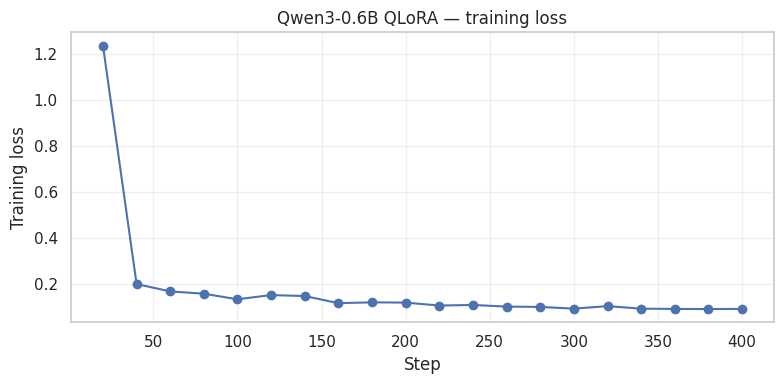

In [19]:
# --- Plot training loss ---
log_history = pd.DataFrame(trainer.state.log_history)
loss_df = log_history.dropna(subset=["loss"])[["step", "loss"]]

_, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_df["step"], loss_df["loss"], marker="o", linewidth=1.5)
ax.set_xlabel("Step")
ax.set_ylabel("Training loss")
ax.set_title("Qwen3-0.6B QLoRA — training loss")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Add Basic Validation

We compare the **base model** vs. the **fine-tuned model** on held-out test splits and enforce lightweight checks before reading the metrics too optimistically.

Metrics included:
- qualitative side-by-side outputs on a fixed prompt set
- Accuracy and macro-F1 (sklearn)
- **Cohen's Kappa** (corrects for class-imbalance / chance agreement)
- **Confusion Matrix** (row-normalized heatmap)
- **BERTScore** (semantic similarity between predicted and reference disease)

In [20]:
DISEASE_REGEX = re.compile(
    r"clinical indication points to:\s*(.+?)(?:\.|\n)", re.IGNORECASE
)


def build_prompt_text(instruction: str, symptoms: str, thinking: bool = False) -> str:
    suffix = " /think" if thinking else " /no_think"
    user_content = f"{instruction}\n\nSymptoms: {symptoms}{suffix}"
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": user_content},
    ]
    return tokenizer.apply_chat_template(
        messages,
        tokenize              = False,
        add_generation_prompt = True,
        enable_thinking       = thinking,
    )


@torch.inference_mode()
def generate_one(mdl, instruction: str, symptoms: str,
                 thinking: bool = False, max_new_tokens: int = 160) -> str:
    prompt = build_prompt_text(instruction, symptoms, thinking)
    inputs = tokenizer(prompt, return_tensors="pt").to(mdl.device)
    out = mdl.generate(
        **inputs,
        max_new_tokens = max_new_tokens,
        do_sample      = True,
        temperature    = 0.7,
        top_p          = 0.8,
        top_k          = 20,
        pad_token_id   = tokenizer.eos_token_id,
    )
    text = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return text.strip()


def extract_disease(text: str) -> str:
    """Extract the disease the model named, falling back to the trimmed first line."""
    if not text:
        return ""
    # Strip Qwen <think> blocks if present
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL).strip()
    m = DISEASE_REGEX.search(text)
    if m:
        return m.group(1).strip().lower()
    # Fallback: first non-empty line, lowercased
    first = next((l.strip() for l in text.splitlines() if l.strip()), "")
    return first.lower()


def normalize_label(s: str) -> str:
    return re.sub(r"\s+", " ", str(s)).strip().lower()


# Switch the (still-loaded, fine-tuned) model into fast inference mode.
FastLanguageModel.for_inference(model)
print("✓ Inference helpers ready.")


✓ Inference helpers ready.


In [21]:
# --- Small end-to-end example after training ---
example_row = ds2_test.sample(1, random_state=SEED).iloc[0]
example_output = generate_one(model, example_row["instruction"], example_row["input"])
print("Prompt:")
print(example_row["instruction"])
print(example_row["input"])
print("\nModel output:\n")
print(example_output)
print("\nExtracted disease:", extract_disease(example_output))

Both `max_new_tokens` (=160) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompt:
Given the symptoms reported, identify the disease.
I've been feeling truly frail in my muscles recently and my neck has been truly solid. Swollen joints make it difficult for me to move around. Walking has also been difficult.

Model output:

Based on the reported symptoms, the clinical indication points to: Arthritis.
Disclaimer: This is an AI auxiliary tool designed for healthcare professionals. It is not 100% precise and does not replace a professional medical diagnosis.

Extracted disease: arthritis


### 5.2 — Qualitative side-by-side: Base vs Fine-tuned

We load the base model **separately** with the LoRA adapter disabled
(`disable_adapter()`), generate on the same prompts, then re-enable the adapter
for the fine-tuned outputs. This avoids loading two full copies of the model in
VRAM.


In [22]:
# Pick a stratified sample of qualitative prompts (some DS1, some DS2)
def pick_qualitative(n: int) -> pd.DataFrame:
    half = max(1, n // 2)
    sample_ds1 = ds1_test.sample(min(half, len(ds1_test)), random_state=SEED)
    sample_ds2 = ds2_test.sample(min(n - len(sample_ds1), len(ds2_test)), random_state=SEED)
    return pd.concat([sample_ds1, sample_ds2], ignore_index=True)


qual_df = pick_qualitative(CONFIG["qualitative_n"])

# Generate with the LoRA adapter DISABLED  → behaves like the base model
base_outputs = []
with model.disable_adapter():
    for row in qual_df.itertuples(index=False):
        base_outputs.append(generate_one(model, row.instruction, row.input))

# Generate with the LoRA adapter enabled (default state)
ft_outputs = [generate_one(model, row.instruction, row.input)
              for row in qual_df.itertuples(index=False)]

qual_results = pd.DataFrame({
    "source":      qual_df["source"].values,
    "symptoms":    qual_df["input"].str.slice(0, 90).values,
    "ground_truth":qual_df["output"].values,
    "base":        base_outputs,
    "fine_tuned":  ft_outputs,
})

with pd.option_context("display.max_colwidth", None):
    display(qual_results[["source", "symptoms", "ground_truth", "base", "fine_tuned"]])


Both `max_new_tokens` (=160) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=160) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=160) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=160) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

,source,symptoms,ground_truth,base,fine_tuned
0,ds1_diseases_symptoms,"white discharge from eye, diminished vision, pain in eye, foreign body sensation in eye, l",corneal abrasion,- **Punctura** (Punctura),"Based on the reported symptoms, the clinical indication points to: conjunctivitis due to foreign body.\nDisclaimer: This is an AI auxiliary tool designed for healthcare professionals. It is not 100% precise and does not replace a professional medical diagnosis."
1,ds1_diseases_symptoms,"difficulty speaking, eye deviation, diminished vision, symptoms of eye",hyperopia,Disease: Strabismus (Strabismus),"Based on the reported symptoms, the clinical indication points to: strabismus.\nDisclaimer: This is an AI auxiliary tool designed for healthcare professionals. It is not 100% precise and does not replace a professional medical diagnosis."
2,ds1_diseases_symptoms,"nasal congestion, diminished hearing, ear pain, ringing in ear, fluid in ear, pulling at e",ear wax impaction,Disease: Encephalopathy (or encephalitis),"Based on the reported symptoms, the clinical indication points to: ear wax impaction.\nDisclaimer: This is an AI auxiliary tool designed for healthcare professionals. It is not 100% precise and does not replace a professional medical diagnosis."
3,ds1_diseases_symptoms,"sharp abdominal pain, weakness",poisoning due to antihypertensives,Disease: acute gastritis,"Based on the reported symptoms, the clinical indication points to: hypocalcemia.\nDisclaimer: This is an AI auxiliary tool designed for healthcare professionals. It is not 100% precise and does not replace a professional medical diagnosis."
4,ds2_symptom2disease,I've been feeling truly frail in my muscles recently and my neck has been truly solid. Swo,Arthritis,Disease: Amyotrophic lateral dystrophy spectrum (ALD),"Based on the reported symptoms, the clinical indication points to: Arthritis.\nDisclaimer: This is an AI auxiliary tool designed for healthcare professionals. It is not 100% precise and does not replace a professional medical diagnosis."
5,ds2_symptom2disease,"My desire for sex has dropped, and I'm having trouble having sex. I frequently get brain f",drug reaction,Disease: Depression (major depressive disorder),"Based on the reported symptoms, the clinical indication points to: Migraine.\nDisclaimer: This is an AI auxiliary tool designed for healthcare professionals. It is not 100% precise and does not replace a professional medical diagnosis."
6,ds2_symptom2disease,"I feel quite weak, and my lymph nodes are enlarged. My eyes are burning, and my throat hur",Common Cold,Disease: Sinusitis,"Based on the reported symptoms, the clinical indication points to: Sinusitis.\nDisclaimer: This is an AI auxiliary tool designed for healthcare professionals. It is not 100% precise and does not replace a professional medical diagnosis."
7,ds2_symptom2disease,I have been frequently getting sudden strong urges to pee. There is blood in my pee someti,urinary tract infection,**Urinary tract infection (UTI)**,"Based on the reported symptoms, the clinical indication points to: urinary tract obstruction.\nDisclaimer: This is an AI auxiliary tool designed for healthcare professionals. It is not 100% precise and does not replace a professional medical diagnosis."


### 5.3 — Quantitative metrics (Accuracy, F1-macro, Cohen's Kappa)


In [23]:
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score
from tqdm.auto import tqdm


def stratified_eval_sample(df: pd.DataFrame, cap: int) -> pd.DataFrame:
    """Cap to `cap` rows while preserving class balance as much as possible."""
    if "output" not in df.columns:
        raise KeyError(f"Expected column 'output', got: {df.columns.tolist()}")
    if len(df) <= cap:
        return df.reset_index(drop=True)

    shuffled = df.sample(frac=1.0, random_state=SEED)
    per_class = max(1, cap // shuffled["output"].nunique())

    sampled = (
        shuffled.groupby("output", group_keys=False)
        .head(per_class)
    )

    if len(sampled) < cap:
        remainder = shuffled.drop(index=sampled.index)
        sampled = pd.concat([sampled, remainder.head(cap - len(sampled))])
    elif len(sampled) > cap:
        sampled = sampled.head(cap)

    sampled = sampled.reset_index(drop=True)
    assert "output" in sampled.columns, "The stratified sample must keep the 'output' column."
    return sampled


def predict_dataframe(mdl, df: pd.DataFrame, desc: str) -> list[str]:
    preds = []
    for row in tqdm(df.itertuples(index=False), total=len(df), desc=desc):
        text = generate_one(mdl, row.instruction, row.input)
        preds.append(extract_disease(text))
    return preds


def compute_metrics(y_true: list[str], y_pred: list[str]) -> dict:
    yt = [normalize_label(s) for s in y_true]
    yp = [normalize_label(s) for s in y_pred]
    return {
        "accuracy":     accuracy_score(yt, yp),
        "f1_macro":     f1_score(yt, yp, average="macro", zero_division=0),
        "cohen_kappa":  cohen_kappa_score(yt, yp),
        "n":            len(yt),
    }


eval_ds1 = stratified_eval_sample(ds1_test, CONFIG["eval_max_samples"])
eval_ds2 = stratified_eval_sample(ds2_test, CONFIG["eval_max_samples"])
print(f"Eval DS1 sample: {len(eval_ds1)}  |  Eval DS2 sample: {len(eval_ds2)}")
print("DS1 columns:", eval_ds1.columns.tolist())
print("DS2 columns:", eval_ds2.columns.tolist())

Eval DS1 sample: 300  |  Eval DS2 sample: 120
DS1 columns: ['instruction', 'input', 'output', 'source']
DS2 columns: ['instruction', 'input', 'output', 'source']


In [24]:
# --- Generate predictions for both eval splits, base + fine-tuned ---
predictions = {}

# Fine-tuned (adapter enabled)
predictions["ft_ds1"] = predict_dataframe(model, eval_ds1, "FT  · DS1")
predictions["ft_ds2"] = predict_dataframe(model, eval_ds2, "FT  · DS2")

# Base (adapter disabled)
with model.disable_adapter():
    predictions["base_ds1"] = predict_dataframe(model, eval_ds1, "Base · DS1")
    predictions["base_ds2"] = predict_dataframe(model, eval_ds2, "Base · DS2")

print("✓ Inference complete.")


FT  · DS1:   0%|          | 0/300 [00:00<?, ?it/s]

Both `max_new_tokens` (=160) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=160) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=160) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=160) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

FT  · DS2:   0%|          | 0/120 [00:00<?, ?it/s]

Both `max_new_tokens` (=160) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=160) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=160) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=160) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

Base · DS1:   0%|          | 0/300 [00:00<?, ?it/s]

Both `max_new_tokens` (=160) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=160) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=160) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=160) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

Base · DS2:   0%|          | 0/120 [00:00<?, ?it/s]

Both `max_new_tokens` (=160) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=160) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=160) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=160) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

✓ Inference complete.


In [25]:
# --- Compute and display metrics ---
metrics_rows = []
for source_name, eval_df in [("DS1", eval_ds1), ("DS2", eval_ds2)]:
    for variant in ["base", "ft"]:
        m = compute_metrics(
            eval_df["output"].tolist(),
            predictions[f"{variant}_{source_name.lower()}"],
        )
        m["model"]  = "Fine-tuned" if variant == "ft" else "Base"
        m["source"] = source_name
        metrics_rows.append(m)

metrics_df = pd.DataFrame(metrics_rows)[
    ["model", "source", "n", "accuracy", "f1_macro", "cohen_kappa"]
].sort_values(["source", "model"])
metrics_df


,model,source,n,accuracy,f1_macro,cohen_kappa
0,Base,DS1,300,0.00,0.000000,-0.000022
1,Fine-tuned,DS1,300,0.13,0.072458,0.128480
2,Base,DS2,120,0.00,0.000000,0.000000
3,Fine-tuned,DS2,120,0.30,0.103985,0.282818


In [26]:
# --- Basic validation checks ---
assert metrics_df.query("source == 'DS2' and model == 'Fine-tuned'").shape[0] == 1

ft_ds2_acc = metrics_df.query("source == 'DS2' and model == 'Fine-tuned'")["accuracy"].iloc[0]
base_ds2_acc = metrics_df.query("source == 'DS2' and model == 'Base'")["accuracy"].iloc[0]
ft_ds2_kappa = metrics_df.query("source == 'DS2' and model == 'Fine-tuned'")["cohen_kappa"].iloc[0]

print({
    "ft_ds2_accuracy": ft_ds2_acc,
    "base_ds2_accuracy": base_ds2_acc,
    "ft_ds2_kappa": ft_ds2_kappa,
})

assert ft_ds2_acc >= base_ds2_acc, "Fine-tuned model should outperform or match base accuracy on DS2."
print("✓ Basic validation passed up to the quantitative metrics stage.")

{'ft_ds2_accuracy': np.float64(0.3), 'base_ds2_accuracy': np.float64(0.0), 'ft_ds2_kappa': np.float64(0.2828175026680897)}
✓ Basic validation passed up to the quantitative metrics stage.


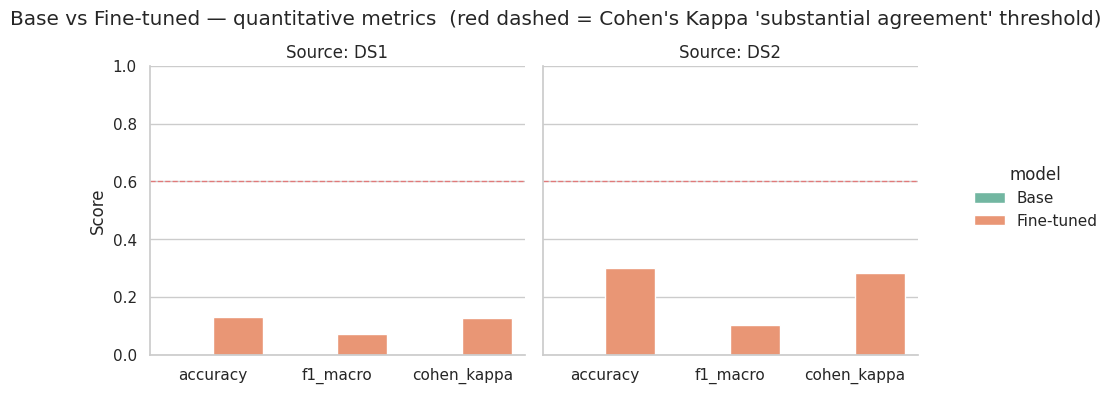

In [27]:
# --- Plot Accuracy / F1 / Kappa side-by-side ---
plot_df = metrics_df.melt(
    id_vars=["model", "source"],
    value_vars=["accuracy", "f1_macro", "cohen_kappa"],
    var_name="metric", value_name="score",
)

g = sns.catplot(
    data=plot_df, kind="bar",
    x="metric", y="score", hue="model", col="source",
    palette="Set2", height=4, aspect=1.1,
)
g.set_titles("Source: {col_name}")
g.set(ylim=(0, 1.0))
for ax in g.axes.ravel():
    ax.axhline(0.6, color="red", linestyle="--", alpha=0.4, linewidth=1)
    ax.set_ylabel("Score")
    ax.set_xlabel("")
plt.suptitle("Base vs Fine-tuned — quantitative metrics  "
             "(red dashed = Cohen's Kappa 'substantial agreement' threshold)",
             y=1.04)
plt.show()


### 5.4 — Confusion Matrix (visual)

Row-normalized (recall per class). Annotations are shown only on cells whose
value exceeds a 5% threshold to keep the plot readable. For Dataset 1 we
restrict the matrix to the **20 most-confused** classes (largest off-diagonal
mass); Dataset 2 (24 classes) fits in full.


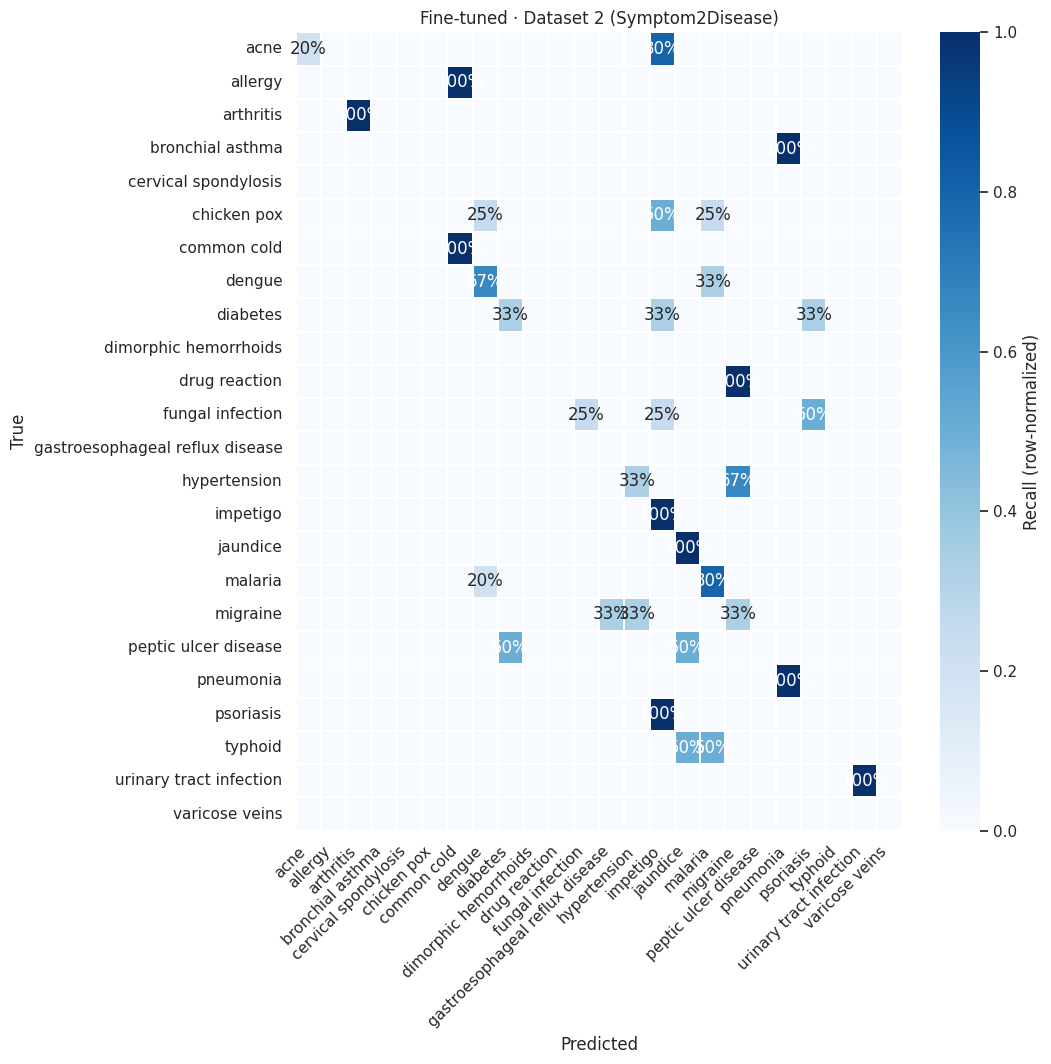

In [28]:
from sklearn.metrics import confusion_matrix


def plot_confusion(y_true, y_pred, title: str,
                   max_classes: int = 24, annot_threshold: float = 0.05):
    yt = [normalize_label(s) for s in y_true]
    yp = [normalize_label(s) for s in y_pred]

    labels = sorted(set(yt))
    cm = confusion_matrix(yt, yp, labels=labels, normalize="true")

    # Restrict to most-confused subset if too many classes
    if len(labels) > max_classes:
        # Score each true-class by off-diagonal mass and keep the top ones
        off_diag_mass = cm.sum(axis=1) - np.diag(cm)
        top_idx = np.argsort(off_diag_mass)[::-1][:max_classes]
        keep = sorted(top_idx.tolist())
        labels = [labels[i] for i in keep]
        cm = cm[np.ix_(keep, keep)]
        # Re-normalize rows (some predictions may now fall outside the kept set)
        row_sums = cm.sum(axis=1, keepdims=True)
        cm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums > 0)
        title = f"{title}  (top-{max_classes} most-confused classes)"

    annot = np.where(cm >= annot_threshold,
                     np.vectorize(lambda v: f"{v:.0%}")(cm), "")
    _, ax = plt.subplots(figsize=(max(8, len(labels) * 0.45),
                                  max(7, len(labels) * 0.45)))
    sns.heatmap(
        cm, annot=annot, fmt="", cmap="Blues",
        xticklabels=labels, yticklabels=labels,
        cbar_kws={"label": "Recall (row-normalized)"},
        linewidths=0.3, linecolor="white", ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# DS2: full 24-class matrix for the fine-tuned model
plot_confusion(
    eval_ds2["output"].tolist(), predictions["ft_ds2"],
    "Fine-tuned · Dataset 2 (Symptom2Disease)"
)


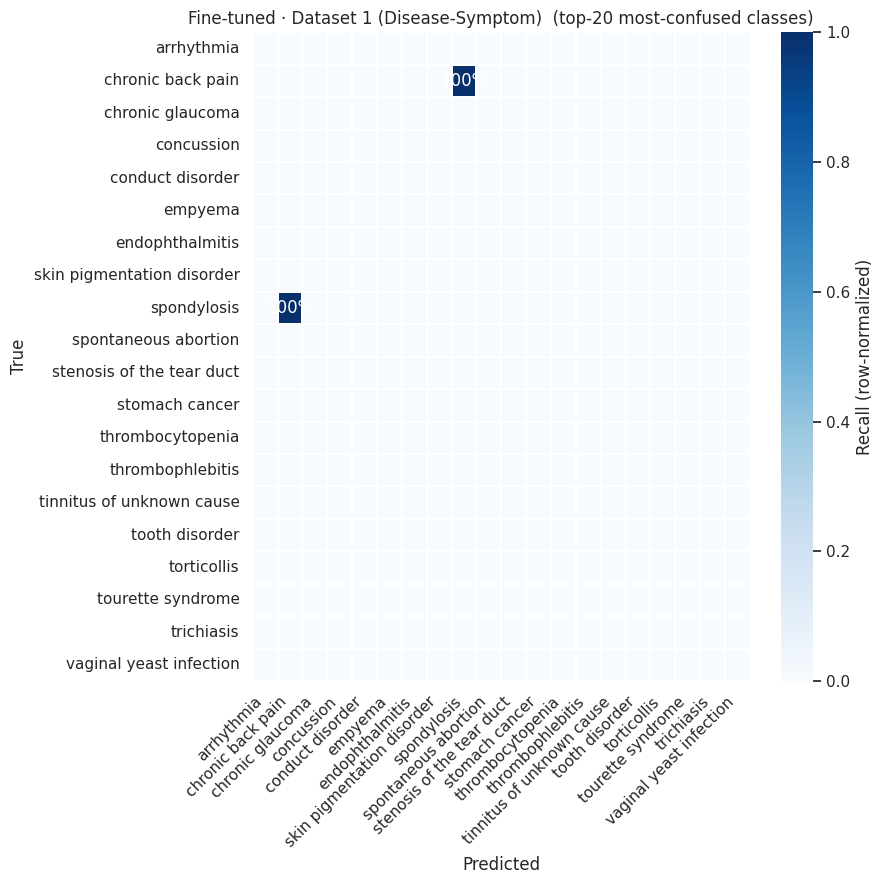

In [29]:
# DS1: too many classes for a single readable matrix → top-20 subset
plot_confusion(
    eval_ds1["output"].tolist(), predictions["ft_ds1"],
    "Fine-tuned · Dataset 1 (Disease-Symptom)",
    max_classes=20,
)


**Reading the matrix.** Diagonal cells = correct classifications. Off-diagonal
cells reveal *where* the model errs:

- *Acceptable* confusions are between diseases that share clinical signatures —
  e.g. **dengue ↔ malaria ↔ typhoid** (overlapping fever syndromes), or
  **common cold ↔ bronchial asthma**.
- *Concerning* confusions cross physiological systems —
  e.g. **diabetes ↔ conjunctivitis**, or **arthritis ↔ peptic ulcer disease**.
  These indicate the model is keying on superficial token overlap rather than
  clinical content.


### 5.5 — BERTScore (semantic similarity)

Even when the predicted disease string doesn't match the reference verbatim,
the prediction may be semantically close (e.g. *"flu"* vs. *"influenza"*).
BERTScore captures this by comparing contextual embeddings of the two strings.

We use `distilbert-base-uncased` to fit the scoring model alongside the
fine-tuned LLM in T4 VRAM. For higher fidelity, swap in `roberta-large` (and
free the LLM first with `del model; torch.cuda.empty_cache()`).


In [30]:
import evaluate

bertscore = evaluate.load("bertscore")


def run_bertscore(refs, preds):
    res = bertscore.compute(
        predictions = [str(p) for p in preds],
        references  = [str(r) for r in refs],
        model_type  = CONFIG["bertscore_model_type"],
        lang        = "en",
    )
    return {
        "precision_mean": float(np.mean(res["precision"])),
        "recall_mean":    float(np.mean(res["recall"])),
        "f1_mean":        float(np.mean(res["f1"])),
        "f1_std":         float(np.std(res["f1"])),
        "f1_per_sample":  res["f1"],
    }


bs_results = {}
for source_name, eval_df in [("DS1", eval_ds1), ("DS2", eval_ds2)]:
    refs = eval_df["output"].tolist()
    bs_results[("Base",       source_name)] = run_bertscore(refs, predictions[f"base_{source_name.lower()}"])
    bs_results[("Fine-tuned", source_name)] = run_bertscore(refs, predictions[f"ft_{source_name.lower()}"])

bs_summary = pd.DataFrame([
    {
        "model":   k[0],
        "source":  k[1],
        "BERT-P":  v["precision_mean"],
        "BERT-R":  v["recall_mean"],
        "BERT-F1": v["f1_mean"],
        "BERT-F1 std": v["f1_std"],
    }
    for k, v in bs_results.items()
]).sort_values(["source", "model"])
bs_summary


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,model,source,BERT-P,BERT-R,BERT-F1,BERT-F1 std
0,Base,DS1,0.690351,0.732559,0.710165,0.050622
1,Fine-tuned,DS1,0.765589,0.769886,0.767157,0.109721
2,Base,DS2,0.669885,0.739206,0.701785,0.061146
3,Fine-tuned,DS2,0.805092,0.803782,0.803798,0.140609


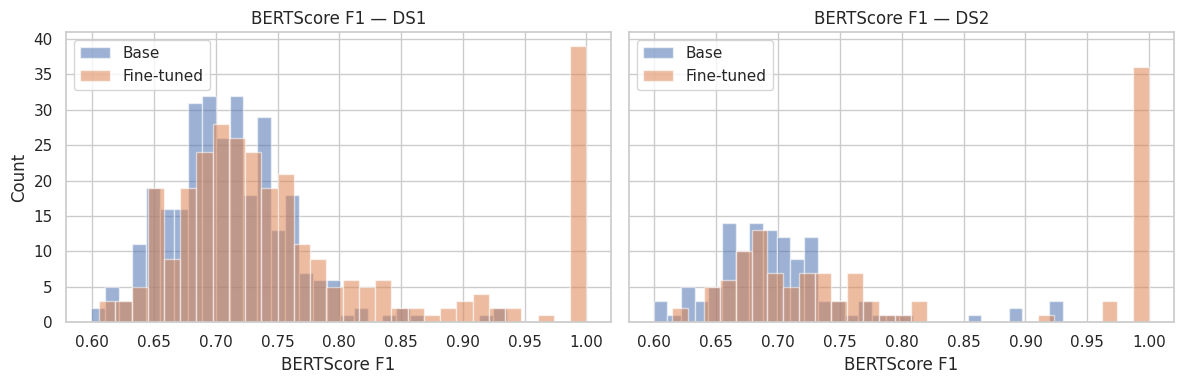

In [31]:
# --- BERTScore F1 distribution histogram ---
_, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, source_name in zip(axes, ["DS1", "DS2"]):
    for variant in ["Base", "Fine-tuned"]:
        ax.hist(
            bs_results[(variant, source_name)]["f1_per_sample"],
            bins=30, alpha=0.55, label=variant,
        )
    ax.set_title(f"BERTScore F1 — {source_name}")
    ax.set_xlabel("BERTScore F1")
    ax.legend()
axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()


## Phase 6 — Export

Save the LoRA adapter, then export a self-contained **GGUF** file
(`q4_k_m` quantization) for local inference with `llama.cpp` / `llama-cpp-python` /
Ollama / LM Studio.


In [33]:
from google.colab import drive
drive.mount('/content/drive')
GDRIVE_ROOT = Path("/content/drive/MyDrive/screening_robot")
GDRIVE_ROOT.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


In [34]:
# --- Save LoRA adapter (small, ~few MB) ---
lora_dir = str(GDRIVE_ROOT / CONFIG["lora_dir"])
model.save_pretrained(lora_dir)
tokenizer.save_pretrained(lora_dir)
print(f"LoRA adapter saved to: {lora_dir}")


LoRA adapter saved to: /content/drive/MyDrive/screening_robot/qwen3-clinical-lora


In [35]:
# --- Merge LoRA into the 16-bit model and write a GGUF file ---
# This runs llama.cpp's converter under the hood and may take several minutes.
gguf_dir = str(GDRIVE_ROOT / CONFIG["gguf_dir"])

model.save_pretrained_gguf(
    gguf_dir,
    tokenizer,
    quantization_method = "q4_k_m",
)

gguf_files = sorted(Path(gguf_dir).rglob("*.gguf"))
for f in gguf_files:
    size_mb = f.stat().st_size / 1024**2
    print(f"  {f}  ({size_mb:.1f} MB)")


Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/752 [00:00<?, ?B/s]

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:00<00:00, 1471.17it/s]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:50<00:00, 50.23s/it]


Unsloth: Merge process complete. Saved to `/content/drive/MyDrive/screening_robot/qwen3-clinical-gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Cloning llama.cpp repository...
Unsloth: Building llama.cpp - please wait 1 to 3 minutes
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...


Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['/content/drive/MyDrive/screening_robot/qwen3-clinical-gguf_gguf/qwen3-0.6b.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['/content/drive/MyDrive/screening_robot/qwen3-clinical-gguf_gguf/qwen3-0.6b.Q4_K_M.gguf']
Unsloth: example usage for text only LLMs: /root/.unsloth/llama.cpp/llama-cli --model /content/drive/MyDrive/screening_robot/qwen3-clinical-gguf_gguf/qwen3-0.6b.Q4_K_M.gguf -p "why is the sky blue?"
Unsloth: Saved Ollama Modelfile to /content/drive/MyDrive/screening_robot/qwen3-clinical-gguf_gguf/Modelfile
Unsloth: convert model to ollama format by running - ollama create model_name -f /content/drive/MyDrive/screening_robot/qwen3-clinical-gguf_gguf/Modelfile


### 6.1 — Local inference test (`llama-cpp-python`)

Smoke-test the GGUF artifact in a fresh process. Install the runtime and load
the file produced above. The Qwen3 chat template (`<|im_start|>...<|im_end|>`)
is embedded in the GGUF, so we just hand `create_chat_completion` a list of
messages.


In [36]:
# Free GPU memory before loading the GGUF runtime
del trainer, model
gc.collect()
torch.cuda.empty_cache()

%pip install -q llama-cpp-python


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 MB 14.1 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.1 MB/s eta 0:00:00


In [43]:
# list files in the GGUF directory to verify the output
# /content/drive/MyDrive/screening_robot/qwen3-clinical-gguf_gguf/
gguf_dir = '/content/drive/MyDrive/screening_robot/qwen3-clinical-gguf_gguf/'
print(list(Path(gguf_dir).glob('*')))

[PosixPath('/content/drive/MyDrive/screening_robot/qwen3-clinical-gguf_gguf/qwen3-0.6b.Q4_K_M.gguf'), PosixPath('/content/drive/MyDrive/screening_robot/qwen3-clinical-gguf_gguf/Modelfile')]


In [46]:
from llama_cpp import Llama

gguf_path = str(sorted(Path(gguf_dir).rglob("*.gguf"))[0])
print(f"Loading: {gguf_path}")

llm = Llama(
    model_path = gguf_path,
    n_ctx      = 2048,
    n_threads  = os.cpu_count() or 4,
    n_gpu_layers = -1,   # offload all layers to GPU if available
    verbose    = False,
)

resp = llm.create_chat_completion(
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": (
            "Given the symptoms reported, identify the disease.\n\n"
            "Symptoms: high fever, severe headache, joint and muscle pain, "
            "skin rash, nausea /no_think"
        )},
    ],
    temperature = 0.7,
    top_p       = 0.8,
    max_tokens  = 160,
)
print(resp["choices"][0]["message"]["content"])


Loading: /content/drive/MyDrive/screening_robot/qwen3-clinical-gguf_gguf/qwen3-0.6b.Q4_K_M.gguf


llama_context: n_ctx_seq (2048) < n_ctx_train (40960) -- the full capacity of the model will not be utilized


<think>

</think>

Based on the reported symptoms, the clinical indication points to: disseminated intravascular thrombosis (dits).
Disclaimer: This is an AI auxiliary tool designed for healthcare professionals. It is not 100% precise and does not replace a professional medical diagnosis.


### 6.2 — Run with `llama.cpp` CLI

```bash
./llama-cli \
    --model qwen3-clinical-gguf/unsloth.Q4_K_M.gguf \
    --ctx-size 2048 \
    --n-gpu-layers 99 \
    --temp 0.7 --top-p 0.8 --top-k 20 --min-p 0 \
    -no-cnv \
    --prompt $'<|im_start|>system\nYou are a clinical AI assistant.<|im_end|>\n<|im_start|>user\nGiven the symptoms reported, identify the disease.\n\nSymptoms: high fever, severe headache, joint and muscle pain, skin rash, nausea /no_think<|im_end|>\n<|im_start|>assistant\n'
```

### 6.3 — Run with Ollama

```bash
# Convert and import the GGUF into Ollama (one-time)
echo 'FROM ./qwen3-clinical-gguf/unsloth.Q4_K_M.gguf' > Modelfile
ollama create qwen3-clinical -f Modelfile
ollama run qwen3-clinical "Given the symptoms reported, identify the disease.

Symptoms: high fever, severe headache, joint and muscle pain, skin rash, nausea /no_think"
```

---

✅ **Notebook complete.** You now have:
- A LoRA adapter (`qwen3-clinical-lora/`) for further training or merging.
- A standalone GGUF (`qwen3-clinical-gguf/*.gguf`) for offline / edge deployment.
- A reproducible evaluation report covering Accuracy, F1-macro, Cohen's Kappa,
  Confusion Matrices and BERTScore vs. the base Qwen3-0.6B.
